<a href="https://colab.research.google.com/github/sanil04/SYSC-4415-Assignment-2/blob/main/W2026/Assignments/A2/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [1]:
# Import all the necessary libraries here

import pandas as pd
import os


import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Sklearn Metrics
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Libraries loaded! Using device: {device}")

Libraries loaded! Using device: cuda


Mount Google Drive and unzip the dataset.

In [2]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
#train_data_path = "/content/train"
#valid_data_path = "/content/valid"
#train_label = pd.read_csv('/content/train/_classes.csv')
#valid_label = pd.read_csv('/content/valid/_classes.csv')


# Changing data set paths to match updated zip with test images
train_data_path = "/content/FH_detection_data/train"
valid_data_path = "/content/FH_detection_data/valid"

train_df = pd.read_csv('/content/FH_detection_data/train/_classes.csv')
valid_df = pd.read_csv('/content/FH_detection_data/valid/_classes.csv')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/FH_detection_data/
   creating: /content/FH_detection_data/test_images/
  inflating: /content/FH_detection_data/test_images/695066.jpg  
  inflating: /content/FH_detection_data/test_images/7a6e6521-ce8d-44bc-851b-7bc619157776-large16x9_FIRE2.jpg  
  inflating: /content/FH_detection_data/test_images/street-view-10.jpg  
  inflating: /content/FH_detection_data/test_images/Street_View_urban_street_(Unsplash).jpg  
  inflating: /content/FH_detection_data/test_images/Surprise-Fire-Hydrant-Appears-on-Lawn-scaled.jpg  
   creating: /content/FH_detection_data/train/
  inflating: /content/FH_detection_data/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
  inflating: /content/FH_detection_data/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
  inflating: /content/FH_detection_data/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
  inflating: /content/F

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ Your answer here
..


It is important to check for class imbalance prior to training as a model trained on skewed data will naturually bias towards the larger class. For example if 90% of the training images contained no hydrant the model could just predict "no hydrant" everytime and be right 90% of the time.

Training Samples:


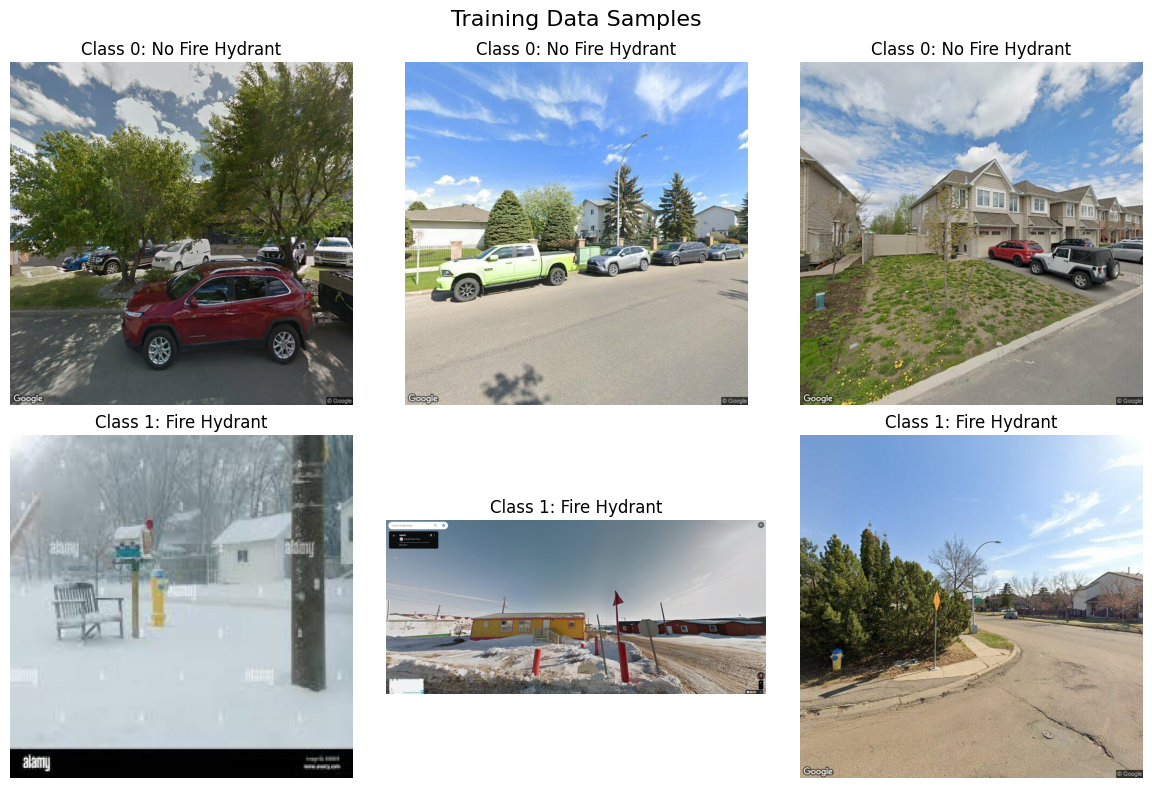

/tmp/ipykernel_6529/3471194280.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='label', ax=axes[0], palette='viridis')
/tmp/ipykernel_6529/3471194280.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=valid_df, x='label', ax=axes[1], palette='viridis')


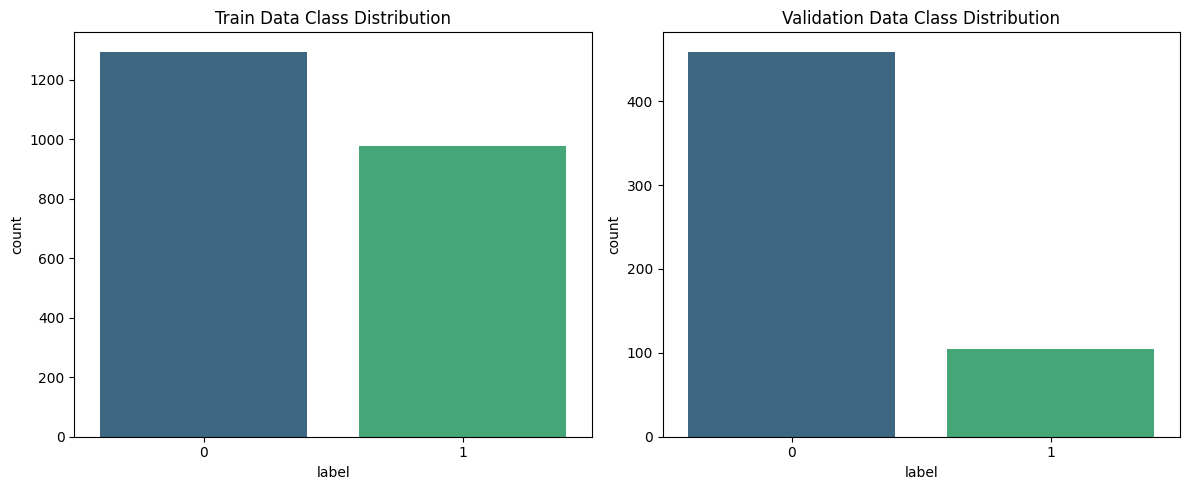

In [3]:
## Enter your code here..

# Load dataset into a pandas DataFrame
train_df = pd.read_csv('/content/FH_detection_data/train/_classes.csv')
valid_df = pd.read_csv('/content/FH_detection_data/valid/_classes.csv')

# Rename the column 'Fire Hydrants' to 'label' for easier access
train_df.rename(columns={'Fire Hydrants': 'label'}, inplace=True)
valid_df.rename(columns={'Fire Hydrants': 'label'}, inplace=True)

# Display three sample images from each class
def plot_samples(df, data_path, title):
    class_0 = df[df['label'] == 0].sample(3, random_state=42)
    class_1 = df[df['label'] == 1].sample(3, random_state=42)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(title, fontsize=16)

    for i, (_, row) in enumerate(class_0.iterrows()):
        img_path = os.path.join(data_path, row['filename'])
        img = Image.open(img_path)
        axes[0, i].imshow(img)
        axes[0, i].set_title("Class 0: No Fire Hydrant")
        axes[0, i].axis('off')

    for i, (_, row) in enumerate(class_1.iterrows()):
        img_path = os.path.join(data_path, row['filename'])
        img = Image.open(img_path)
        axes[1, i].imshow(img)
        axes[1, i].set_title("Class 1: Fire Hydrant")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

print("Training Samples:")
plot_samples(train_df, train_data_path, "Training Data Samples")

# Create separately class distribution plots of the train and validation data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=train_df, x='label', ax=axes[0], palette='viridis')
axes[0].set_title('Train Data Class Distribution')

sns.countplot(data=valid_df, x='label', ax=axes[1], palette='viridis')
axes[1].set_title('Validation Data Class Distribution')

plt.tight_layout()
plt.show()


---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ Your answer here..

One-hot encoding is not nessecary for binary classification. This is because there are only two possible states those being "no hydrant" and "hydrant". If there were more than two it should be used to stop a mathmetical bias being caused by states having higher numerical values.

In [4]:
## Enter your code here..


# Create standard transformations: Resize to 128x128, convert to tensor, and normalize
base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Define a custom PyTorch Dataset
class FireHydrantDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        # Open image and convert to RGB
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.dataframe.iloc[idx]['label'], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

# Create DataLoaders
train_dataset = FireHydrantDataset(train_df, train_data_path, transform=base_transform)
valid_dataset = FireHydrantDataset(valid_df, valid_data_path, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅ Your answer here..

In [5]:
## Enter your code here..


class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # Input: 3 channels, Output: 32 channels, Kernel: 3, Padding: 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        # MaxPool2d (kernel size 2, stride 2, padding 0) -> Reduces spatial dimensions by half (128 -> 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # Input: 32 channels, Output: 64 channels, Kernel: 3, Padding: 1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        # MaxPool2d -> Reduces spatial dimensions by half again (64 -> 32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # Flattened size: 64 channels * 32 width * 32 height = 65536
        self.flatten = nn.Flatten()

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

baseline_model = BaselineCNN().to(device)
print(baseline_model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ Your answer here


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ Your answer here


--- Training Baseline CNN ---
Epoch [1/10], Loss: 0.6329
Epoch [2/10], Loss: 0.5109
Epoch [3/10], Loss: 0.4747
Epoch [4/10], Loss: 0.4296
Epoch [5/10], Loss: 0.3802
Epoch [6/10], Loss: 0.3172
Epoch [7/10], Loss: 0.2579
Epoch [8/10], Loss: 0.1630
Epoch [9/10], Loss: 0.1061
Epoch [10/10], Loss: 0.0618

--- Results for Baseline CNN ---
Precision: 0.3206 | Recall: 0.8077 | F1-Score: 0.4590


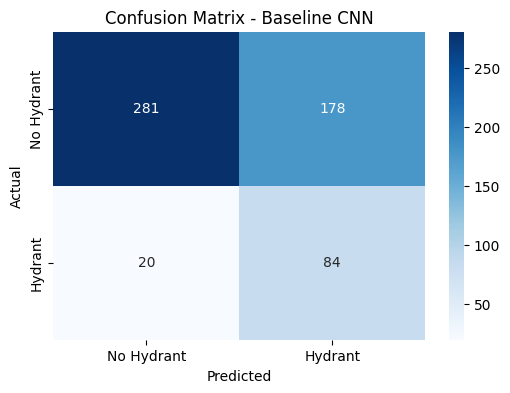

In [6]:
## Enter your code here..

def train_and_evaluate(model, train_loader, valid_loader, epochs=10, lr=0.001, model_name="Baseline CNN"):
    print(f"\n--- Training {model_name} ---")

    criterion = nn.BCELoss() # Binary Cross Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training Loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1) # shape [batch_size, 1]

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Evaluation Loop
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            outputs = model(images).cpu()

            preds = (outputs >= 0.5).float() # Threshold at 0.5
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    # Calculate metrics
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n--- Results for {model_name} ---")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Hydrant', 'Hydrant'],
                yticklabels=['No Hydrant', 'Hydrant'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Run the baseline training
train_and_evaluate(baseline_model, train_loader, valid_loader, epochs=10, lr=0.001, model_name="Baseline CNN")

---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ Your answer here


--- Training Dropout CNN ---
Epoch [1/10], Loss: 0.5877
Epoch [2/10], Loss: 0.4942
Epoch [3/10], Loss: 0.4435
Epoch [4/10], Loss: 0.3787
Epoch [5/10], Loss: 0.3134
Epoch [6/10], Loss: 0.2549
Epoch [7/10], Loss: 0.1842
Epoch [8/10], Loss: 0.1361
Epoch [9/10], Loss: 0.1076
Epoch [10/10], Loss: 0.0931

--- Results for Dropout CNN ---
Precision: 0.4710 | Recall: 0.6250 | F1-Score: 0.5372


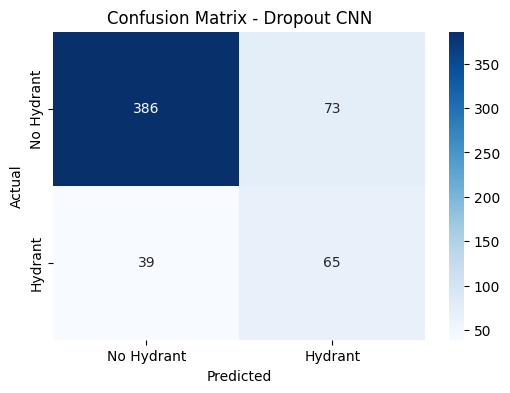


--- Training BatchNorm CNN ---
Epoch [1/10], Loss: 2.3346
Epoch [2/10], Loss: 0.6215
Epoch [3/10], Loss: 0.5291
Epoch [4/10], Loss: 0.5173
Epoch [5/10], Loss: 0.3619
Epoch [6/10], Loss: 0.3565
Epoch [7/10], Loss: 0.2746
Epoch [8/10], Loss: 0.2160
Epoch [9/10], Loss: 0.1944
Epoch [10/10], Loss: 0.1207

--- Results for BatchNorm CNN ---
Precision: 0.3846 | Recall: 0.7212 | F1-Score: 0.5017


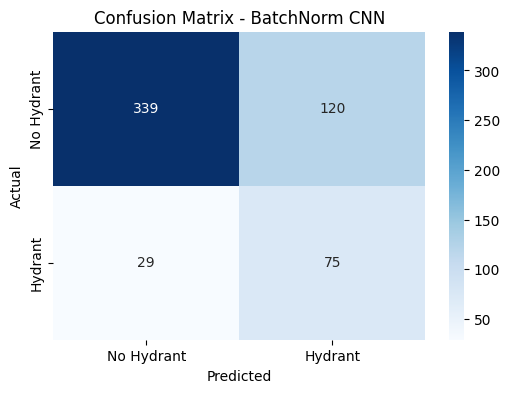


--- Training Augmentation CNN ---
Epoch [1/10], Loss: 0.6471
Epoch [2/10], Loss: 0.5130
Epoch [3/10], Loss: 0.4686
Epoch [4/10], Loss: 0.4369
Epoch [5/10], Loss: 0.4069
Epoch [6/10], Loss: 0.3745
Epoch [7/10], Loss: 0.3431
Epoch [8/10], Loss: 0.3006
Epoch [9/10], Loss: 0.2595
Epoch [10/10], Loss: 0.2411

--- Results for Augmentation CNN ---
Precision: 0.4621 | Recall: 0.6442 | F1-Score: 0.5382


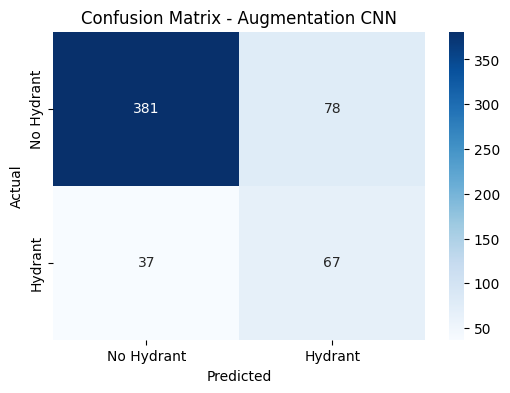

In [7]:
## Enter your code here..

# --- Improvement 1: Dropout Model ---
class DropoutCNN(BaselineCNN):
    def __init__(self):
        super(DropoutCNN, self).__init__()
        # Override the fully connected layer block to include Dropout
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # 50% probability of dropping out neurons
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

# --- Improvement 2: Batch Normalization Model ---
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Added BN Layer
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) # Added BN Layer
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# --- Improvement 3: Data Augmentation DataLoaders ---
aug_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5), # Randomly mirror images
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Random light adjustments
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

aug_train_dataset = FireHydrantDataset(train_df, train_data_path, transform=aug_transform)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=32, shuffle=True)

# 1. Train Dropout
dropout_model = DropoutCNN().to(device)
train_and_evaluate(dropout_model, train_loader, valid_loader, model_name="Dropout CNN")

# 2. Train Batch Norm
bn_model = BatchNormCNN().to(device)
train_and_evaluate(bn_model, train_loader, valid_loader, model_name="BatchNorm CNN")

# 3. Train Baseline on Augmented Data
aug_model = BaselineCNN().to(device)
train_and_evaluate(aug_model, aug_train_loader, valid_loader, model_name="Augmentation CNN")

---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Your answer here

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ Your answer here


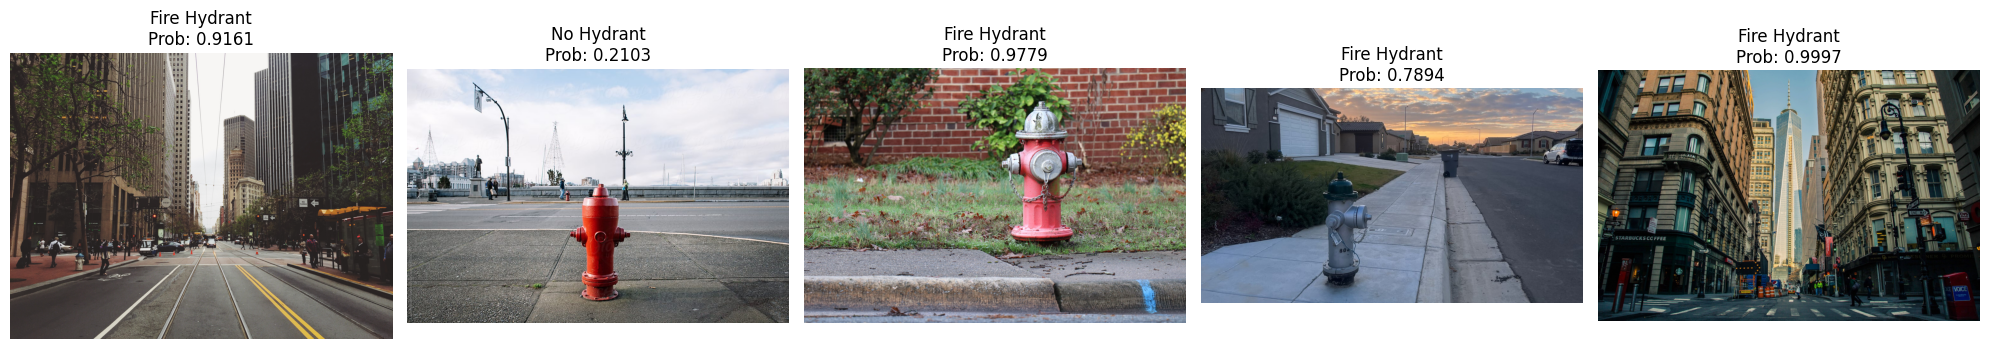

In [8]:
## Enter your code here..


# Note: Upload your 5 images into a folder named "test_images" in your Colab files menu
import glob

# Ensure folder exists to avoid code crashing, user needs to populate it manually
test_dir = '/content/FH_detection_data/test_images'
os.makedirs(test_dir, exist_ok=True)

# Select the best performing model from the previous step to run inference (e.g., aug_model)
best_model = aug_model
best_model.eval()

# We only use the standard resizing transform for inference (no random data augments!)
inference_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

image_paths = glob.glob(f"{test_dir}/*.*") # Gets all images in the folder

if not image_paths:
    print("Please upload 5 images to the '/content/test_images' folder to run this cell.")
else:
    fig, axes = plt.subplots(1, len(image_paths), figsize=(20, 5))
    if len(image_paths) == 1:
        axes = [axes] # Handle single image formatting

    for i, img_path in enumerate(image_paths):
        img = Image.open(img_path).convert("RGB")
        img_tensor = inference_transform(img).unsqueeze(0).to(device) # Add batch dimension

        with torch.no_grad():
            output = best_model(img_tensor).item()

        prediction = "Fire Hydrant" if output >= 0.5 else "No Hydrant"
        axes[i].imshow(img)
        axes[i].set_title(f"{prediction}\nProb: {output:.4f}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ Your answer here..


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ Your answer here..


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

